In [6]:
"""
============================================================
02_treinamento_modelo.py
Monitoramento Térmico — Polimento de Aço
============================================================
Pipeline de dois modelos:

  MODELO 1 — Classificador (EfficientNet-B3)
    Entrada : frame grayscale + temperatura normalizada (2ch)
    Saída   : Normal / Atenção / Crítico
    Labels  : gerados pelo script de extração (por temperatura)

  MODELO 2 — Segmentador (U-Net com backbone ResNet34)
    Entrada : frame + mapa de ativação do classificador (Grad-CAM)
    Saída   : mapa de probabilidade de anomalia por pixel
    Labels  : pseudo-masks via Grad-CAM do classificador treinado
              (MUITO mais estável que pseudo-labels por AE)

Saídas:
  checkpoints/classifier_best.pt
  checkpoints/unet_best.pt
  resultados/  → curvas, grades de inferência
  frames_marcados/ → PNGs com overlay + marcações

Dependências:
    pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
    pip install pillow numpy matplotlib tqdm scikit-learn tensorboard opencv-python timm
============================================================
"""

'\n============================================================\n02_treinamento_modelo.py\nMonitoramento Térmico — Polimento de Aço\n============================================================\nPipeline de dois modelos:\n\n  MODELO 1 — Classificador (EfficientNet-B3)\n    Entrada : frame grayscale + temperatura normalizada (2ch)\n    Saída   : Normal / Atenção / Crítico\n    Labels  : gerados pelo script de extração (por temperatura)\n\n  MODELO 2 — Segmentador (U-Net com backbone ResNet34)\n    Entrada : frame + mapa de ativação do classificador (Grad-CAM)\n    Saída   : mapa de probabilidade de anomalia por pixel\n    Labels  : pseudo-masks via Grad-CAM do classificador treinado\n              (MUITO mais estável que pseudo-labels por AE)\n\nSaídas:\n  checkpoints/classifier_best.pt\n  checkpoints/unet_best.pt\n  resultados/  → curvas, grades de inferência\n  frames_marcados/ → PNGs com overlay + marcações\n\nDependências:\n    pip install torch torchvision torchaudio --index-url ht

In [8]:
# ════════════════════════════════════════════════════════════
#  0. CONFIGURAÇÕES
# ════════════════════════════════════════════════════════════
from pathlib import Path

BASE_DIR        = Path(r"/mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/monitoramento-termico")
FRAMES_MODELO   = BASE_DIR / "frames_model_input"       # PNGs grayscale 320×240
META_JSON       = BASE_DIR / "frames_metadata.json"
CHECKPOINTS_DIR = BASE_DIR / "checkpoints"
RESULTS_DIR     = BASE_DIR / "resultados"
FRAMES_MARCADOS = BASE_DIR / "frames_marcados"

for d in [CHECKPOINTS_DIR, RESULTS_DIR, FRAMES_MARCADOS]:
    d.mkdir(exist_ok=True)

# ── Hiperparâmetros ───────────────────────────────────────
IMG_SIZE     = (240, 320)   # (H, W)
BATCH_SIZE   = 16
SEED         = 13
TRAIN_SPLIT  = 0.80
VAL_SPLIT    = 0.10
# test_split = 0.10 (implícito)

# Classificador
EPOCHS_CLS   = 50
LR_CLS       = 3e-4
PATIENCE_CLS = 12
DROPOUT_CLS  = 0.40         # alto para prevenir overfitting no head

# U-Net
EPOCHS_UNET  = 40
LR_UNET      = 1e-4
PATIENCE_UNET= 12
DROPOUT_UNET = 0.20

# Grad-CAM → pseudo-mask
GRADCAM_THRESH_PERCENTIL = 70   # pixels acima do percentil 70 do mapa → anômalos

# Threshold de deploy: frame com >X% pixels anômalos → anomalia
ANOMALY_SCORE_THRESHOLD = 5.0

# Classes
CLASS_NAMES = ["normal", "atencao", "critico"]
NUM_CLASSES  = len(CLASS_NAMES)

print("Configurações carregadas ✓")

Configurações carregadas ✓


In [9]:
# ════════════════════════════════════════════════════════════
#  1. IMPORTS, GPU, SEEDS
# ════════════════════════════════════════════════════════════
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
import torchvision.transforms as T
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
import json
import random
import csv
import math
from tqdm import tqdm

try:
    import timm
    HAS_TIMM = True
except ImportError:
    HAS_TIMM = False
    print("ℹ️  timm não disponível — usando EfficientNet-B3 do torchvision (comportamento idêntico).")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✅ GPU: {gpu_name}  ({gpu_mem:.1f} GB)")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    torch.backends.cudnn.benchmark        = True
    torch.backends.cudnn.deterministic    = False
else:
    print("⚠️  GPU não encontrada — usando CPU (treinamento lento)")

print(f"Device: {device}")

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

ℹ️  timm não disponível — usando EfficientNet-B3 do torchvision (comportamento idêntico).
✅ GPU: NVIDIA GeForce RTX 5090 Laptop GPU  (25.7 GB)
Device: cuda


In [10]:
# ════════════════════════════════════════════════════════════
#  2. METADADOS
# ════════════════════════════════════════════════════════════
with open(META_JSON, "r") as jf:
    META = json.load(jf)

G_MIN  = META["global_stats"]["min_absoluto"]
G_MAX  = META["global_stats"]["max_absoluto"]
G_MEAN = META["global_stats"]["mean_das_medias"]
G_STD  = META["global_stats"]["std_das_medias"]

THRESH_ATENCAO = META["limiares_classificacao"]["thresh_atencao"]
THRESH_CRITICO = META["limiares_classificacao"]["thresh_critico"]

# Corrige NaN residuais
if any(not math.isfinite(v) for v in [G_MIN, G_MAX, G_MEAN, G_STD]):
    print("⚠️  NaN nas estatísticas globais — recalculando...")
    vals = [f["mean_abs"] for f in META["frames"] if f.get("mean_abs") and math.isfinite(f["mean_abs"])]
    G_MIN  = float(min(f["min_abs"] for f in META["frames"] if math.isfinite(f.get("min_abs", float("nan")))))
    G_MAX  = float(max(f["max_abs"] for f in META["frames"] if math.isfinite(f.get("max_abs", float("nan")))))
    G_MEAN = float(np.mean(vals))
    G_STD  = float(np.std(vals))

FRAME_META = {f"frame_{f['seq_id']:06d}": f for f in META["frames"]}

# Verifica labels
label_counts = {c: 0 for c in CLASS_NAMES}
for f in META["frames"]:
    lbl = f.get("label", "normal")
    if lbl in label_counts:
        label_counts[lbl] += 1

print(f"Frames no JSON : {len(META['frames'])}")
print(f"Temp. global   : min={G_MIN:.2f}°C  max={G_MAX:.2f}°C  mean={G_MEAN:.2f}°C")
print(f"Limiares       : atenção={THRESH_ATENCAO:.2f}°C  crítico={THRESH_CRITICO:.2f}°C")
print(f"Labels         : {label_counts}")

if label_counts.get("critico", 0) < 30:
    print("\n⚠️  AVISO CRÍTICO: muito poucos frames 'critico'!")
    print("   O modelo pode não aprender esta classe adequadamente.")
    print("   Soluções: reduza PERCENTIL_CRITICO na extração, ou colete mais dados.")



Frames no JSON : 1992
Temp. global   : min=-241.41°C  max=758.89°C  mean=17.93°C
Limiares       : atenção=18.14°C  crítico=20.05°C
Labels         : {'normal': 1022, 'atencao': 264, 'critico': 706}


In [11]:
# ════════════════════════════════════════════════════════════
#  3. DATASET DE 2 CANAIS
# ════════════════════════════════════════════════════════════
class ThermalDataset(Dataset):
    """
    Canal 0: frame grayscale normalizado localmente [0,1]  — padrão espacial térmico
    Canal 1: temperatura média absoluta normalizada globalmente — contexto do processo

    O canal 1 é FUNDAMENTAL para o modelo distinguir frames com mesmo padrão espacial
    mas temperaturas absolutas diferentes (ex: aquecimento gradual normal vs. crítico).
    """
    def __init__(self, files, frame_meta, img_size, augment=False):
        self.files    = files
        self.meta     = frame_meta
        self.img_size = img_size
        self.augment  = augment
        H, W          = img_size
        self.resize   = T.Resize((H, W), antialias=True)
        self.to_tensor = T.ToTensor()

        # Augmentações controladas — não distorcem informação térmica
        self.aug = T.Compose([
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.3),
            T.RandomRotation(degrees=8),
            T.RandomAffine(degrees=0, translate=(0.04, 0.04)),
            # SEM ColorJitter forte — altera o padrão térmico
            T.ColorJitter(brightness=0.08, contrast=0.08),
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        stem = path.stem
        info = self.meta.get(stem, {})

        img = Image.open(path).convert("L")
        img = self.resize(img)

        if self.augment:
            img = self.aug(img)

        ch1 = self.to_tensor(img)  # (1, H, W) em [0,1]

        mean_norm = float(info.get("mean_norm_global", 0.5))
        ch2 = torch.full_like(ch1, mean_norm)

        x = torch.cat([ch1, ch2], dim=0)  # (2, H, W)

        # Label para classificação
        label_str = info.get("label", "normal")
        label_idx = CLASS_NAMES.index(label_str) if label_str in CLASS_NAMES else 0

        return x, label_idx, stem


def make_splits(frame_meta, frames_dir, img_size, train_split, val_split, seed):
    """
    Split estratificado por classe para evitar que uma classe fique ausente
    no conjunto de validação.
    """
    all_files = sorted(frames_dir.glob("*.png"))

    # Agrupa por classe
    by_class = {c: [] for c in CLASS_NAMES}
    for fp in all_files:
        stem = fp.stem
        lbl  = frame_meta.get(stem, {}).get("label", "normal")
        if lbl in by_class:
            by_class[lbl].append(fp)

    rng = random.Random(seed)
    train_files, val_files, test_files = [], [], []

    for cls, files in by_class.items():
        rng.shuffle(files)
        n       = len(files)
        n_train = max(1, int(n * train_split))
        n_val   = max(1, int(n * val_split))
        train_files.extend(files[:n_train])
        val_files.extend(files[n_train:n_train + n_val])
        test_files.extend(files[n_train + n_val:])
        print(f"  {cls:8s}: {n:4d} total → {n_train} treino | {n_val} val | {n - n_train - n_val} teste")

    rng.shuffle(train_files)
    rng.shuffle(val_files)
    rng.shuffle(test_files)

    ds_train = ThermalDataset(train_files, frame_meta, img_size, augment=True)
    ds_val   = ThermalDataset(val_files,   frame_meta, img_size, augment=False)
    ds_test  = ThermalDataset(test_files,  frame_meta, img_size, augment=False)

    return ds_train, ds_val, ds_test, train_files, val_files, test_files


print("\nCriando splits estratificados...")
ds_train, ds_val, ds_test, train_files, val_files, test_files = make_splits(
    FRAME_META, FRAMES_MODELO, IMG_SIZE, TRAIN_SPLIT, VAL_SPLIT, SEED
)

# ── WeightedRandomSampler para balancear classes no treino ──
# Essencial quando "critico" << "normal"
class_counts = np.array([
    sum(1 for f in train_files if FRAME_META.get(f.stem, {}).get("label") == c)
    for c in CLASS_NAMES
], dtype=np.float32)
class_counts = np.maximum(class_counts, 1)  # evita divisão por zero
class_weights = 1.0 / class_counts
sample_weights = [
    class_weights[CLASS_NAMES.index(FRAME_META.get(f.stem, {}).get("label", "normal"))]
    for f in train_files
]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

import platform
_NUM_WORKERS = 0 if platform.system() == "Windows" else 4

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, sampler=sampler,
                      num_workers=_NUM_WORKERS, pin_memory=True,
                      persistent_workers=(_NUM_WORKERS > 0))
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=_NUM_WORKERS, pin_memory=True,
                      persistent_workers=(_NUM_WORKERS > 0))
dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=_NUM_WORKERS, pin_memory=True)

print(f"\nTreino: {len(ds_train)} | Validação: {len(ds_val)} | Teste: {len(ds_test)}")
batch_x, batch_y, batch_stems = next(iter(dl_train))
print(f"Batch shape: {batch_x.shape} | Labels: {batch_y[:8].tolist()}")



Criando splits estratificados...
  normal  : 1022 total → 817 treino | 102 val | 103 teste
  atencao :  264 total → 211 treino | 26 val | 27 teste
  critico :  706 total → 564 treino | 70 val | 72 teste

Treino: 1592 | Validação: 198 | Teste: 202
Batch shape: torch.Size([16, 2, 240, 320]) | Labels: [0, 0, 1, 0, 2, 0, 0, 1]


In [12]:
# ════════════════════════════════════════════════════════════
#  4. MODELO 1 — CLASSIFICADOR (EfficientNet-B3)
# ════════════════════════════════════════════════════════════
class ThermalClassifier(nn.Module):
    """
    EfficientNet-B3 pré-treinado adaptado para 2 canais de entrada.

    Usa timm se disponível; caso contrário, usa torchvision (mesma arquitetura,
    mesmos pesos ImageNet). A lógica de fine-tuning e Grad-CAM é compatível
    com ambos os backends.

    Por que EfficientNet-B3 e não Autoencoder?
    - EfficientNet é treinado de forma SUPERVISIONADA com labels reais
    - Aprende diretamente as features que distinguem Normal/Atenção/Crítico
    - B3 é o melhor trade-off entre acurácia e velocidade para GPU

    Por que não YOLO?
    - YOLO detecta OBJETOS com bounding boxes — não adequado para mapas
      de temperatura difusos sem objetos discretos.
    - Para SEGMENTAÇÃO de regiões térmicas, U-Net é superior.
    """
    # Nome da camada alvo do Grad-CAM — varia conforme o backend
    GRADCAM_LAYER_TIMM = "backbone.blocks.6"
    GRADCAM_LAYER_TV   = "backbone.features.7"  # features.7 = último MBConv block

    def __init__(self, num_classes=3, dropout=0.40):
        super().__init__()
        self._backend = "timm" if HAS_TIMM else "torchvision"

        if HAS_TIMM:
            # ── backend timm ──────────────────────────────────────
            self.backbone = timm.create_model(
                "efficientnet_b3",
                pretrained=True,
                num_classes=0,       # Remove head original
                global_pool="avg",
                in_chans=1,          # timm adapta o primeiro conv automaticamente
            )
            feat_dim = self.backbone.num_features  # 1536
        else:
            # ── backend torchvision (sem timm) ───────────────────
            _tv = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
            # Adapta o primeiro conv de 3→1 canal (média dos 3 canais originais)
            orig = _tv.features[0][0]
            new_conv = nn.Conv2d(
                1, orig.out_channels,
                kernel_size=orig.kernel_size,
                stride=orig.stride,
                padding=orig.padding,
                bias=False,
            )
            with torch.no_grad():
                new_conv.weight.copy_(orig.weight.mean(dim=1, keepdim=True))
            _tv.features[0][0] = new_conv
            feat_dim = _tv.classifier[1].in_features  # 1536
            _tv.classifier = nn.Identity()
            # Adiciona global average pooling explícito (torchvision mantém o avgpool)
            self.backbone = _tv

        # Head customizado com regularização forte
        self.head = nn.Sequential(
            nn.BatchNorm1d(feat_dim),
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 256),
            nn.SiLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, num_classes),
        )

        # Inicializa o head corretamente
        nn.init.xavier_uniform_(self.head[-1].weight)
        nn.init.zeros_(self.head[-1].bias)

        # Congela backbone nas primeiras épocas (fine-tuning progressivo)
        self._freeze_backbone()

    def _freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def _unfreeze_backbone(self, unfreeze_blocks=3):
        """Descongela os últimos N blocos para fine-tuning."""
        for p in self.backbone.parameters():
            p.requires_grad = True
        if self._backend == "timm":
            for name, p in self.backbone.named_parameters():
                if any(f"blocks.{i}" in name for i in range(5 - unfreeze_blocks)):
                    p.requires_grad = False
        else:
            # torchvision: congela features.0...(7-unfreeze_blocks)
            freeze_until = 8 - unfreeze_blocks
            for name, p in self.backbone.named_parameters():
                idx = None
                parts = name.split(".")
                if parts[0] == "features" and len(parts) > 1:
                    try:
                        idx = int(parts[1])
                    except ValueError:
                        pass
                if idx is not None and idx < freeze_until:
                    p.requires_grad = False

    def _extract_features(self, x1ch):
        """
        Extrai vetor de features (B, feat_dim) do canal espacial.
        Compatível com ambos os backends.
        """
        if self._backend == "timm":
            return self.backbone(x1ch)
        else:
            # torchvision: forward inclui avgpool + flatten internamente
            return self.backbone(x1ch)  # retorna (B, 1536) por causa do Identity

    def forward(self, x):
        feat = self._extract_features(x[:, 0:1])  # (B, feat_dim)
        return self.head(feat)                     # (B, num_classes)

    def get_features(self, x):
        """Para Grad-CAM — retorna feature map (B, C, h, w) antes do pooling."""
        if self._backend == "timm":
            return self.backbone.forward_features(x[:, 0:1])
        else:
            # torchvision: passa apenas pelas features convolucionais
            return self.backbone.features(x[:, 0:1])

    @property
    def gradcam_layer_name(self):
        """Nome da camada alvo do Grad-CAM conforme o backend."""
        if self._backend == "timm":
            return self.GRADCAM_LAYER_TIMM
        return self.GRADCAM_LAYER_TV


# Verifica parâmetros
classifier = ThermalClassifier(NUM_CLASSES, DROPOUT_CLS).to(device)
params_cls = sum(p.numel() for p in classifier.parameters() if p.requires_grad)
params_total = sum(p.numel() for p in classifier.parameters())
print(f"\nClassificador EfficientNet-B3")
print(f"  Parâmetros treináveis : {params_cls:,}")
print(f"  Parâmetros totais     : {params_total:,}")


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /home/cesarmacieira/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:06<00:00, 7.16MB/s]



Classificador EfficientNet-B3
  Parâmetros treináveis : 397,827
  Parâmetros totais     : 11,093,339


In [13]:
# ════════════════════════════════════════════════════════════
#  5. LOSS: LABEL SMOOTHING + PESOS DE CLASSE
# ════════════════════════════════════════════════════════════
# Label smoothing: evita que o modelo fique 100% confiante — reduz overfitting
# Pesos de classe: penaliza mais os erros na classe minoritária "critico"
class_weight_tensor = torch.tensor(class_weights / class_weights.sum() * NUM_CLASSES,
                                   dtype=torch.float32).to(device)
cls_criterion = nn.CrossEntropyLoss(
    weight=class_weight_tensor,
    label_smoothing=0.10   # suaviza labels: 0.9 para classe correta, 0.05 para outras
)

In [14]:
# ════════════════════════════════════════════════════════════
#  6. EARLY STOPPING + UTILS
# ════════════════════════════════════════════════════════════
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-5, mode="min"):
        self.patience  = patience
        self.min_delta = min_delta
        self.mode      = mode
        self.counter   = 0
        self.best      = float("inf") if mode == "min" else float("-inf")
        self.stop      = False

    def step(self, metric):
        improved = (
            (metric < self.best - self.min_delta) if self.mode == "min"
            else (metric > self.best + self.min_delta)
        )
        if improved:
            self.best    = metric
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        return self.stop


@torch.no_grad()
def accuracy(logits, labels):
    return (logits.argmax(dim=1) == labels).float().mean().item()


@torch.no_grad()
def per_class_accuracy(logits, labels, num_classes):
    preds = logits.argmax(dim=1)
    acc   = {}
    for c in range(num_classes):
        mask = labels == c
        if mask.sum() > 0:
            acc[CLASS_NAMES[c]] = (preds[mask] == c).float().mean().item()
    return acc


Treinando Classificador por até 50 épocas...
  Fase 1 (épocas 1–8): head only
  Fase 2 (épocas 9+): fine-tuning backbone parcial


CLS 001 [head] | loss=1.0900/0.9798 | acc=0.708/0.837 | normal:0.97  atencao:0.58  critico:0.71 | lr=3.00e-04 ← ✓


CLS 002 [head] | loss=0.8542/0.7710 | acc=0.763/0.833 | normal:0.80  atencao:0.88  critico:0.86 | lr=3.00e-04


CLS 003 [head] | loss=0.7798/0.8204 | acc=0.754/0.615 | normal:0.43  atencao:0.96  critico:0.77 | lr=3.00e-04


CLS 004 [head] | loss=0.6774/0.7306 | acc=0.784/0.806 | normal:0.85  atencao:0.88  critico:0.73 | lr=3.00e-04


...

CLS 040 [finetune] | loss=0.3872/0.5046 | acc=0.936/0.942 | normal:0.92  atencao:0.92  critico:0.97 | lr=3.00e-05


CLS 041 [finetune] | loss=0.3765/0.5034 | acc=0.941/0.928 | normal:0.90  atencao:0.92  critico:0.96 | lr=3.00e-05


CLS 042 [finetune] | loss=0.3779/0.4953 | acc=0.936/0.947 | normal:0.95  atencao:0.92  critico:0.94 | lr=3.00e-05


CLS 043 [finetune] | loss=0.3680/0.4989 | acc=0.950/0.942 | normal:0.92  atencao:0.92  critico:0.97 | lr=3.00e-05


CLS 044 [finetune] | loss=0.3776/0.4813 | acc=0.943/0.952 | normal:0.94  atencao:0.92  critico:0.97 | lr=3.00e-05
Early stopping na época 44.

✅ Melhor val_acc Classificador: 0.9567


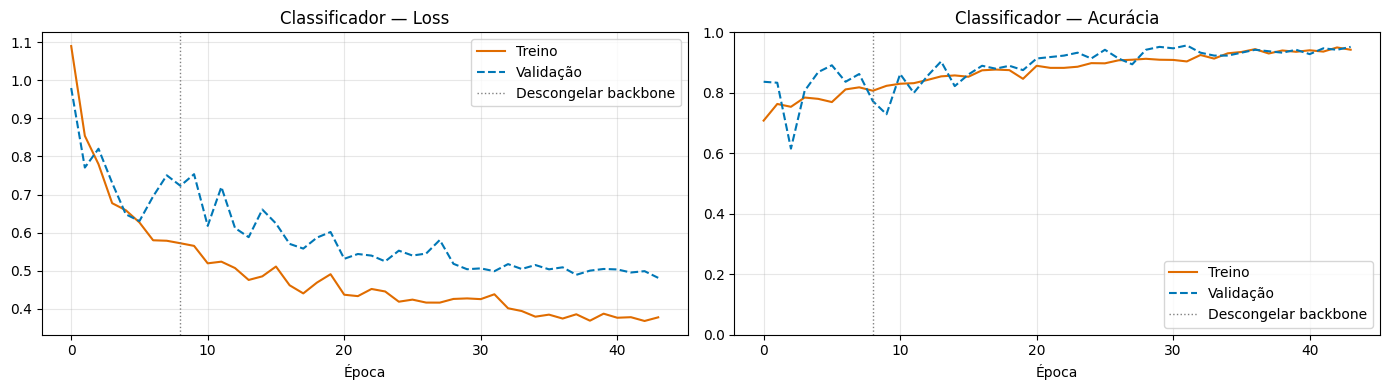

In [15]:
# ════════════════════════════════════════════════════════════
#  7. TREINAMENTO DO CLASSIFICADOR (2 FASES)
# ════════════════════════════════════════════════════════════
"""
Fase 1 (épocas 1–10): apenas o head é treinado, backbone congelado.
  → Estabiliza o head antes do fine-tuning.

Fase 2 (épocas 11+): backbone descongelado parcialmente.
  → Fine-tuning com LR menor no backbone.
"""

# ── Fase 1: treina só o head ──────────────────────────────
opt_cls   = optim.AdamW(filter(lambda p: p.requires_grad, classifier.parameters()),
                        lr=LR_CLS, weight_decay=1e-3)
scaler    = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())
es_cls    = EarlyStopping(patience=PATIENCE_CLS, mode="max")  # monitora acurácia val

hist_cls  = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0
UNFREEZE_EPOCH = 8   # época em que descongela backbone

log_cls = open(RESULTS_DIR / "cls_log.csv", "w", newline="")
csv_cls = csv.writer(log_cls)
csv_cls.writerow(["epoch", "phase", "train_loss", "val_loss", "train_acc", "val_acc", "lr"])

print(f"\nTreinando Classificador por até {EPOCHS_CLS} épocas...")
print(f"  Fase 1 (épocas 1–{UNFREEZE_EPOCH}): head only")
print(f"  Fase 2 (épocas {UNFREEZE_EPOCH+1}+): fine-tuning backbone parcial")

for epoch in range(1, EPOCHS_CLS + 1):

    # ── Descongelamento progressivo na Fase 2 ──
    if epoch == UNFREEZE_EPOCH + 1:
        print(f"\n  → Fase 2: descongelando backbone parcial...")
        classifier._unfreeze_backbone(unfreeze_blocks=3)
        # Recria optimizer com grupos de LR diferente para backbone vs head
        opt_cls = optim.AdamW([
            {"params": [p for n, p in classifier.backbone.named_parameters() if p.requires_grad],
             "lr": LR_CLS * 0.1, "weight_decay": 1e-4},   # backbone: LR 10× menor
            {"params": classifier.head.parameters(),
             "lr": LR_CLS * 0.5, "weight_decay": 1e-4},   # head: LR intermediário
        ])

    phase = "head" if epoch <= UNFREEZE_EPOCH else "finetune"

    # ── Treino ──
    classifier.train()
    t_loss, t_acc = 0.0, 0.0
    for xb, yb, _ in tqdm(dl_train, desc=f"CLS {epoch:03d}/{EPOCHS_CLS}", leave=False):
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        opt_cls.zero_grad()
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            logits = classifier(xb)
            loss   = cls_criterion(logits, yb)
        scaler.scale(loss).backward()
        scaler.unscale_(opt_cls)
        nn.utils.clip_grad_norm_(classifier.parameters(), max_norm=1.0)
        scaler.step(opt_cls)
        scaler.update()
        t_loss += loss.item()
        t_acc  += accuracy(logits, yb)
    t_loss /= len(dl_train)
    t_acc  /= len(dl_train)

    # ── Validação ──
    classifier.eval()
    v_loss, v_acc = 0.0, 0.0
    all_logits, all_labels = [], []
    with torch.no_grad():
        for xb, yb, _ in dl_val:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                logits = classifier(xb)
                v_loss += cls_criterion(logits, yb).item()
            v_acc  += accuracy(logits, yb)
            all_logits.append(logits.cpu())
            all_labels.append(yb.cpu())
    v_loss /= len(dl_val)
    v_acc  /= len(dl_val)

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)
    per_cls    = per_class_accuracy(all_logits, all_labels, NUM_CLASSES)

    lr_now = opt_cls.param_groups[0]["lr"]
    hist_cls["train_loss"].append(t_loss)
    hist_cls["val_loss"].append(v_loss)
    hist_cls["train_acc"].append(t_acc)
    hist_cls["val_acc"].append(v_acc)
    csv_cls.writerow([epoch, phase, f"{t_loss:.6f}", f"{v_loss:.6f}",
                      f"{t_acc:.4f}", f"{v_acc:.4f}", f"{lr_now:.2e}"])
    log_cls.flush()

    flag = ""
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save({
            "epoch": epoch, "model_state": classifier.state_dict(),
            "val_acc": v_acc, "val_loss": v_loss,
            "img_size": IMG_SIZE, "g_min": G_MIN, "g_max": G_MAX,
            "thresh_atencao": THRESH_ATENCAO, "thresh_critico": THRESH_CRITICO,
            "class_names": CLASS_NAMES,
            "backend": classifier._backend,   # registra backend para reload correto
        }, CHECKPOINTS_DIR / "classifier_best.pt")
        flag = " ← ✓"

    per_str = "  ".join(f"{k}:{v:.2f}" for k, v in per_cls.items())
    print(f"CLS {epoch:03d} [{phase}] | loss={t_loss:.4f}/{v_loss:.4f} | "
          f"acc={t_acc:.3f}/{v_acc:.3f} | {per_str} | lr={lr_now:.2e}{flag}")

    if es_cls.step(v_acc):
        print(f"Early stopping na época {epoch}.")
        break

log_cls.close()
print(f"\n✅ Melhor val_acc Classificador: {best_val_acc:.4f}")

# ── Curvas de aprendizado ─────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(hist_cls["train_loss"], label="Treino",    color="#e06c00")
ax1.plot(hist_cls["val_loss"],   label="Validação", color="#0077b6", linestyle="--")
ax1.axvline(UNFREEZE_EPOCH, color="gray", lw=1, linestyle=":", label="Descongelar backbone")
ax1.set_title("Classificador — Loss")
ax1.set_xlabel("Época"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(hist_cls["train_acc"], label="Treino",    color="#e06c00")
ax2.plot(hist_cls["val_acc"],   label="Validação", color="#0077b6", linestyle="--")
ax2.axvline(UNFREEZE_EPOCH, color="gray", lw=1, linestyle=":", label="Descongelar backbone")
ax2.set_title("Classificador — Acurácia")
ax2.set_xlabel("Época"); ax2.legend(); ax2.grid(alpha=0.3); ax2.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "cls_curves.png", dpi=150)
plt.show()


Avaliando no conjunto de teste...

Relatório de Classificação — Conjunto de Teste:
              precision    recall  f1-score   support

      normal       0.99      0.98      0.99       103
     atencao       0.89      0.93      0.91        27
     critico       0.99      0.99      0.99        72

    accuracy                           0.98       202
   macro avg       0.96      0.96      0.96       202
weighted avg       0.98      0.98      0.98       202



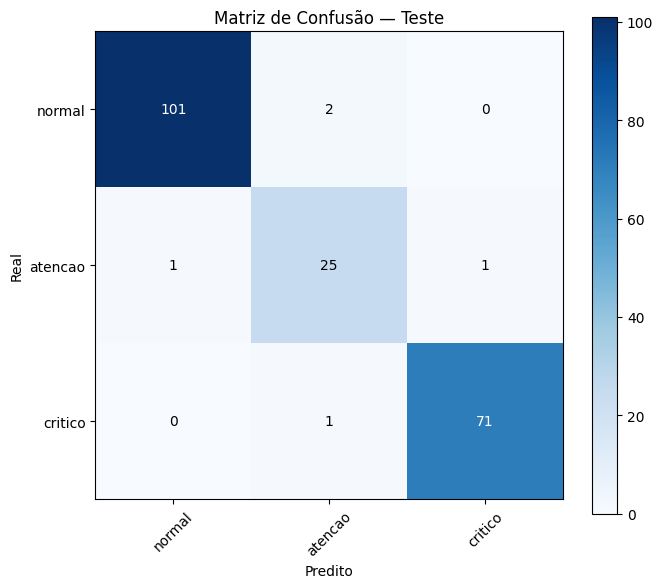

In [16]:
# ════════════════════════════════════════════════════════════
#  8. AVALIAÇÃO NO CONJUNTO DE TESTE
# ════════════════════════════════════════════════════════════
print("\nAvaliando no conjunto de teste...")
ckpt = torch.load(CHECKPOINTS_DIR / "classifier_best.pt", map_location=device, weights_only=False)
classifier.load_state_dict(ckpt["model_state"])
classifier.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb, _ in dl_test:
        xb = xb.to(device, non_blocking=True)
        logits = classifier(xb)
        all_preds.append(logits.argmax(dim=1).cpu())
        all_true.append(yb)

all_preds = torch.cat(all_preds).numpy()
all_true  = torch.cat(all_true).numpy()

from sklearn.metrics import classification_report, confusion_matrix
print("\nRelatório de Classificação — Conjunto de Teste:")
print(classification_report(all_true, all_preds, target_names=CLASS_NAMES))

cm_arr = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_arr, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45)
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, str(cm_arr[i, j]), ha="center", va="center",
                color="white" if cm_arr[i, j] > cm_arr.max() / 2 else "black")
ax.set_xlabel("Predito"); ax.set_ylabel("Real")
ax.set_title("Matriz de Confusão — Teste")
plt.colorbar(im); plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150)
plt.show()

In [17]:
# ════════════════════════════════════════════════════════════
#  9. GRAD-CAM PARA GERAR PSEUDO-MASKS DA U-NET
# ════════════════════════════════════════════════════════════
class GradCAM:
    """
    Grad-CAM: usa gradientes da classe predita em relação ao último
    mapa de feature map para localizar regiões relevantes.

    É MUITO mais confiável que pseudo-labels por reconstrução do AE
    porque usa o gradiente de um classificador SUPERVISIONADO.

    Compatível com backends timm e torchvision via target_layer_name dinâmico.
    """
    def __init__(self, model, target_layer_name=None):
        self.model  = model
        self.grads  = None
        self.feats  = None

        # Usa o nome da camada conforme o backend do modelo
        if target_layer_name is None:
            target_layer_name = getattr(model, "gradcam_layer_name",
                                        "backbone.features.7")

        # Encontra a camada alvo dinamicamente
        target_layer = None
        for name, module in model.named_modules():
            if name == target_layer_name:
                target_layer = module
                break
            elif target_layer_name in name and isinstance(module, (nn.Sequential, nn.Module)):
                target_layer = module

        if target_layer is None:
            # Fallback robusto: último bloco de features
            if hasattr(model, "backbone"):
                bb = model.backbone
                if hasattr(bb, "blocks"):          # timm
                    target_layer = bb.blocks[-1]
                elif hasattr(bb, "features"):      # torchvision
                    target_layer = bb.features[-2]  # features.7 (antes do stem final)
                else:
                    target_layer = list(bb.modules())[-3]
            print(f"⚠️  Camada GradCAM '{target_layer_name}' não encontrada — usando fallback")

        self.handle_f = target_layer.register_forward_hook(self._save_feats)
        self.handle_b = target_layer.register_full_backward_hook(self._save_grads)

    def _save_feats(self, module, input, output):
        # output pode ser tuple em alguns módulos torchvision
        self.feats = (output[0] if isinstance(output, tuple) else output).detach()

    def _save_grads(self, module, grad_input, grad_output):
        self.grads = grad_output[0].detach()

    def generate(self, x, class_idx=None):
        """
        x: (1, 2, H, W)
        Retorna: (H, W) mapa de ativação normalizado em [0,1]
        """
        self.model.eval()
        x = x.requires_grad_(True)

        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        self.model.zero_grad()
        logits[0, class_idx].backward()

        # Grad-CAM: pesos = média global dos gradientes
        weights    = self.grads.mean(dim=(2, 3), keepdim=True)  # (1, C, 1, 1)
        cam        = (weights * self.feats).sum(dim=1)           # (1, h, w)
        cam        = F.relu(cam).squeeze()                       # (h, w) — squeeze seguro
        if cam.dim() == 0:                                       # edge case: h=w=1
            cam = cam.unsqueeze(0).unsqueeze(0)
        cam        = cam.cpu().numpy()

        # Normaliza e redimensiona para o tamanho original
        # NOTA: cv2.resize recebe (width, height) — inverso de (H, W) do tensor
        cam        = cv2.resize(cam, (x.shape[3], x.shape[2]))  # (W, H)
        cam_min, cam_max = cam.min(), cam.max()
        if cam_max > cam_min:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            cam = np.zeros_like(cam)
        return cam, class_idx

    def remove_hooks(self):
        self.handle_f.remove()
        self.handle_b.remove()

In [18]:
# ════════════════════════════════════════════════════════════
#  10. U-NET PARA SEGMENTAÇÃO
# ════════════════════════════════════════════════════════════
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class ThermalUNet(nn.Module):
    """
    U-Net para segmentação de regiões anômalas.
    Entrada: 3 canais [canal_spatial, canal_temp_abs, mapa_gradcam]
    Saída  : mapa de probabilidade de anomalia por pixel (logits)

    O mapa Grad-CAM como canal 3 guia a U-Net para as regiões
    identificadas pelo classificador — muito mais informativo que
    o erro de reconstrução do AE.
    """
    def __init__(self, in_channels=3, base_ch=32, dropout=0.15):
        super().__init__()
        b = base_ch
        self.enc1 = DoubleConv(in_channels, b,    dropout=0.0)
        self.enc2 = DoubleConv(b,           b*2,  dropout=dropout)
        self.enc3 = DoubleConv(b*2,         b*4,  dropout=dropout)
        self.enc4 = DoubleConv(b*4,         b*8,  dropout=dropout)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(b*8, b*16, dropout=dropout)
        self.up4  = nn.ConvTranspose2d(b*16, b*8,  2, stride=2)
        self.dec4 = DoubleConv(b*16, b*8)
        self.up3  = nn.ConvTranspose2d(b*8,  b*4,  2, stride=2)
        self.dec3 = DoubleConv(b*8,  b*4)
        self.up2  = nn.ConvTranspose2d(b*4,  b*2,  2, stride=2)
        self.dec2 = DoubleConv(b*4,  b*2)
        self.up1  = nn.ConvTranspose2d(b*2,  b,    2, stride=2)
        self.dec1 = DoubleConv(b*2,  b)
        self.head = nn.Conv2d(b, 1, 1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.head(d1)  # logits sem sigmoid


unet = ThermalUNet(in_channels=3, base_ch=32, dropout=DROPOUT_UNET).to(device)
params_u = sum(p.numel() for p in unet.parameters() if p.requires_grad)
print(f"\nU-Net — {params_u:,} parâmetros")


U-Net — 7,763,041 parâmetros


In [19]:
# ════════════════════════════════════════════════════════════
#  11. DATASET DA U-NET (GRAD-CAM COMO PSEUDO-MASK)
# ════════════════════════════════════════════════════════════
class UNetDataset(Dataset):
    def __init__(self, x3_cache, mask_cache, augment=False):
        self.x3    = x3_cache
        self.masks = mask_cache
        self.augment = augment

    def __len__(self):
        return len(self.x3)

    def __getitem__(self, idx):
        x3   = self.x3[idx].clone()
        mask = self.masks[idx].clone()
        if self.augment:
            if random.random() < 0.5:
                x3   = torch.flip(x3,   dims=[2])
                mask = torch.flip(mask, dims=[2])
            if random.random() < 0.3:
                x3   = torch.flip(x3,   dims=[1])
                mask = torch.flip(mask, dims=[1])
        return x3, mask


def build_unet_cache(files, frame_meta, classifier, gradcam_thresh_pct,
                     img_size, device, batch_size=8):
    """
    Pré-computa para cada frame:
      x3: [canal_spatial, canal_temp, mapa_gradcam]
      mask: pseudo-mask binária a partir do Grad-CAM

    Frames classificados como "normal" → mask = zeros (sem anomalia).
    Frames "atencao"/"critico" → mask = Grad-CAM > percentil.
    """
    H, W = img_size
    tf   = T.Compose([T.Resize((H, W), antialias=True), T.ToTensor()])

    gradcam = GradCAM(classifier)  # usa gradcam_layer_name do modelo automaticamente
    classifier.eval()

    x3_list, mask_list = [], []

    for path in tqdm(files, desc="Pré-computando cache U-Net (Grad-CAM)"):
        stem      = path.stem
        info      = frame_meta.get(stem, {})
        mean_norm = float(info.get("mean_norm_global", 0.5))
        label     = info.get("label", "normal")

        img  = Image.open(path).convert("L")
        ch1  = tf(img)                              # (1, H, W)
        ch2  = torch.full_like(ch1, mean_norm)      # (1, H, W)
        x2   = torch.cat([ch1, ch2], dim=0).unsqueeze(0).to(device)  # (1, 2, H, W)

        # Gera Grad-CAM
        cam_map, pred_cls = gradcam.generate(x2)    # (H, W) em [0,1]

        ch_cam = torch.from_numpy(cam_map).unsqueeze(0).float()  # (1, H, W)
        x3     = torch.cat([ch1, ch2, ch_cam], dim=0)            # (3, H, W)

        # Pseudo-mask: apenas para frames anômalos preditos
        if label in ("atencao", "critico") or pred_cls > 0:
            thresh = float(np.percentile(cam_map, gradcam_thresh_pct))
            mask_np = (cam_map > thresh).astype(np.float32)
            # Suaviza bordas
            mask_np = cv2.GaussianBlur(mask_np, (7, 7), 0)
        else:
            mask_np = np.zeros((H, W), dtype=np.float32)

        mask = torch.from_numpy(mask_np).unsqueeze(0).float()  # (1, H, W)

        x3_list.append(x3.cpu())
        mask_list.append(mask)

    gradcam.remove_hooks()
    return x3_list, mask_list


all_files = sorted(FRAMES_MODELO.glob("*.png"))
print(f"\nPré-calculando pseudo-masks via Grad-CAM ({len(all_files)} frames)...")
print("Este passo pode demorar alguns minutos...")

x3_cache, mask_cache = build_unet_cache(
    all_files, FRAME_META, classifier,
    GRADCAM_THRESH_PERCENTIL, IMG_SIZE, device,
)

frac_anom = np.mean([m.mean().item() for m in mask_cache])
print(f"Cache: {len(x3_cache)} frames")
print(f"Fração média de pixels anômalos: {frac_anom*100:.2f}%")

if frac_anom < 0.01:
    print("⚠️  Poucos pixels anômalos — considere reduzir GRADCAM_THRESH_PERCENTIL (ex: 60)")
elif frac_anom > 0.60:
    print("⚠️  Muitos pixels anômalos — considere aumentar GRADCAM_THRESH_PERCENTIL (ex: 80)")

# Usa os mesmos índices de split
file_to_idx = {fp: i for i, fp in enumerate(all_files)}
train_indices = [file_to_idx[fp] for fp in train_files if fp in file_to_idx]
val_indices   = [file_to_idx[fp] for fp in val_files   if fp in file_to_idx]

ds_unet_train = UNetDataset([x3_cache[i] for i in train_indices],
                             [mask_cache[i] for i in train_indices], augment=True)
ds_unet_val   = UNetDataset([x3_cache[i] for i in val_indices],
                             [mask_cache[i] for i in val_indices], augment=False)

dlu_train = DataLoader(ds_unet_train, batch_size=BATCH_SIZE // 2, shuffle=True,  num_workers=0)
dlu_val   = DataLoader(ds_unet_val,   batch_size=BATCH_SIZE // 2, shuffle=False, num_workers=0)
print(f"U-Net dataset: {len(ds_unet_train)} treino | {len(ds_unet_val)} val")


Pré-calculando pseudo-masks via Grad-CAM (1992 frames)...
Este passo pode demorar alguns minutos...


Pré-computando cache U-Net (Grad-CAM): 100%|██████████| 1992/1992 [01:33<00:00, 21.36it/s]

Cache: 1992 frames
Fração média de pixels anômalos: 15.49%
U-Net dataset: 1592 treino | 198 val


In [20]:
# ════════════════════════════════════════════════════════════
#  12. LOSS DA U-NET (FOCAL + DICE)
# ════════════════════════════════════════════════════════════
def dice_loss(pred, target, smooth=1e-6):
    p     = torch.sigmoid(pred)
    inter = (p * target).sum(dim=(1, 2, 3))
    union = p.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    return 1 - ((2 * inter + smooth) / (union + smooth)).mean()


def focal_loss(pred, target, gamma=2.0, alpha=0.75):
    """
    Focal Loss para pixels desbalanceados (normal >> anomalia).
    alpha=0.75 pondera mais a classe positiva (pixel anômalo).
    """
    bce   = F.binary_cross_entropy_with_logits(pred, target, reduction="none")
    p_t   = torch.sigmoid(pred) * target + (1 - torch.sigmoid(pred)) * (1 - target)
    alpha_t = alpha * target + (1 - alpha) * (1 - target)
    return (alpha_t * (1 - p_t) ** gamma * bce).mean()


def unet_loss(pred, target):
    """40% Focal + 60% Dice — Dice é mais estável para desbalanceamento."""
    return 0.4 * focal_loss(pred, target) + 0.6 * dice_loss(pred, target)


@torch.no_grad()
def compute_seg_metrics(logits, target, threshold=0.5):
    pred = (torch.sigmoid(logits) > threshold).float()
    tp   = (pred * target).sum().item()
    fp   = (pred * (1 - target)).sum().item()
    fn   = ((1 - pred) * target).sum().item()
    iou  = tp / (tp + fp + fn + 1e-6)
    f1   = 2 * tp / (2 * tp + fp + fn + 1e-6)
    return {"iou": iou, "f1": f1}


Treinando U-Net por até 40 épocas...


UNet 001 | train=0.4111 | val=0.4041 | IoU=0.489 | F1=0.650 | lr=1.00e-04 ← ✓


UNet 002 | train=0.3873 | val=0.3923 | IoU=0.507 | F1=0.666 | lr=1.00e-04 ← ✓


UNet 003 | train=0.3769 | val=0.3799 | IoU=0.532 | F1=0.688 | lr=1.00e-04 ← ✓


UNet 004 | train=0.3715 | val=0.3849 | IoU=0.527 | F1=0.684 | lr=1.00e-04


...

UNet 035 | train=0.3401 | val=0.3544 | IoU=0.681 | F1=0.806 | lr=5.00e-05


UNet 036 | train=0.3398 | val=0.3559 | IoU=0.732 | F1=0.843 | lr=5.00e-05


UNet 037 | train=0.3400 | val=0.3552 | IoU=0.735 | F1=0.846 | lr=5.00e-05


UNet 038 | train=0.3392 | val=0.3564 | IoU=0.663 | F1=0.793 | lr=5.00e-05


UNet 039 | train=0.3390 | val=0.3552 | IoU=0.714 | F1=0.831 | lr=5.00e-05
Early stopping na época 39.

✅ Melhor val_loss U-Net: 0.3531


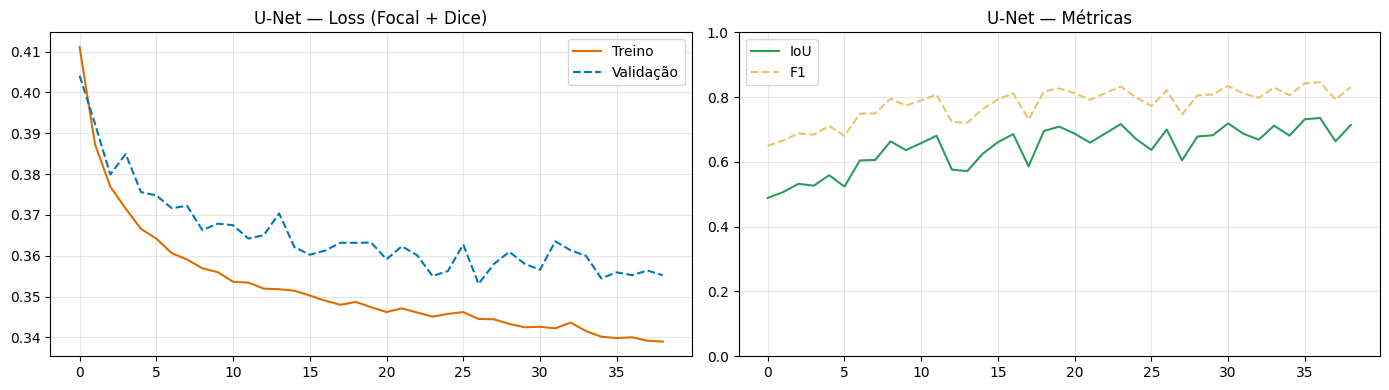

In [21]:
# ════════════════════════════════════════════════════════════
#  13. TREINAMENTO DA U-NET
# ════════════════════════════════════════════════════════════
opt_unet  = optim.AdamW(unet.parameters(), lr=LR_UNET, weight_decay=1e-4)
sched_u   = optim.lr_scheduler.ReduceLROnPlateau(opt_unet, patience=6, factor=0.5, min_lr=1e-6)
es_unet   = EarlyStopping(patience=PATIENCE_UNET, mode="min")
scaler_u  = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

hist_u = {"train": [], "val": [], "iou": [], "f1": []}
best_u = float("inf")

log_u = open(RESULTS_DIR / "unet_log.csv", "w", newline="")
csv_u = csv.writer(log_u)
csv_u.writerow(["epoch", "train_loss", "val_loss", "val_iou", "val_f1", "lr"])

print(f"\nTreinando U-Net por até {EPOCHS_UNET} épocas...")

for epoch in range(1, EPOCHS_UNET + 1):
    unet.train()
    t_loss = 0.0
    for x3, mask in tqdm(dlu_train, desc=f"UNet {epoch:03d}/{EPOCHS_UNET}", leave=False):
        x3, mask = x3.to(device, non_blocking=True), mask.to(device, non_blocking=True)
        opt_unet.zero_grad()
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            loss = unet_loss(unet(x3), mask)
        scaler_u.scale(loss).backward()
        scaler_u.unscale_(opt_unet)
        nn.utils.clip_grad_norm_(unet.parameters(), 1.0)
        scaler_u.step(opt_unet)
        scaler_u.update()
        t_loss += loss.item()
    t_loss /= len(dlu_train)

    unet.eval()
    v_loss, v_iou, v_f1 = 0.0, 0.0, 0.0
    with torch.no_grad():
        for x3, mask in dlu_val:
            x3, mask = x3.to(device, non_blocking=True), mask.to(device, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                logits  = unet(x3)
                v_loss += unet_loss(logits, mask).item()
            m     = compute_seg_metrics(logits, mask)
            v_iou += m["iou"]
            v_f1  += m["f1"]
    v_loss /= len(dlu_val)
    v_iou  /= len(dlu_val)
    v_f1   /= len(dlu_val)

    sched_u.step(v_loss)
    lr_now = opt_unet.param_groups[0]["lr"]
    hist_u["train"].append(t_loss)
    hist_u["val"].append(v_loss)
    hist_u["iou"].append(v_iou)
    hist_u["f1"].append(v_f1)
    csv_u.writerow([epoch, f"{t_loss:.8f}", f"{v_loss:.8f}",
                    f"{v_iou:.4f}", f"{v_f1:.4f}", f"{lr_now:.2e}"])
    log_u.flush()

    flag = ""
    if v_loss < best_u:
        best_u = v_loss
        torch.save({
            "epoch": epoch, "model_state": unet.state_dict(),
            "val_loss": v_loss, "val_iou": v_iou, "val_f1": v_f1,
            "img_size": IMG_SIZE, "g_min": G_MIN, "g_max": G_MAX,
            "gradcam_thresh_pct": GRADCAM_THRESH_PERCENTIL,
            "dropout": DROPOUT_UNET,
        }, CHECKPOINTS_DIR / "unet_best.pt")
        flag = " ← ✓"

    print(f"UNet {epoch:03d} | train={t_loss:.4f} | val={v_loss:.4f} | "
          f"IoU={v_iou:.3f} | F1={v_f1:.3f} | lr={lr_now:.2e}{flag}")

    if es_unet.step(v_loss):
        print(f"Early stopping na época {epoch}.")
        break

log_u.close()
print(f"\n✅ Melhor val_loss U-Net: {best_u:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(hist_u["train"], label="Treino",    color="#e06c00")
ax1.plot(hist_u["val"],   label="Validação", color="#0077b6", linestyle="--")
ax1.set_title("U-Net — Loss (Focal + Dice)"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(hist_u["iou"], label="IoU", color="#2a9d5c")
ax2.plot(hist_u["f1"],  label="F1",  color="#e9c46a", linestyle="--")
ax2.set_title("U-Net — Métricas"); ax2.legend(); ax2.grid(alpha=0.3); ax2.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "unet_curves.png", dpi=150)
plt.show()

In [24]:
# ════════════════════════════════════════════════════════════
#  14. PIPELINE DE INFERÊNCIA EM TEMPO REAL
# ════════════════════════════════════════════════════════════
def carregar_pipeline(checkpoints_dir, device):
    """Carrega ambos os modelos para inferência."""
    ckpt_cls  = torch.load(checkpoints_dir / "classifier_best.pt",  map_location=device, weights_only=False)
    ckpt_unet = torch.load(checkpoints_dir / "unet_best.pt",        map_location=device, weights_only=False)

    cls = ThermalClassifier(num_classes=len(ckpt_cls["class_names"]), dropout=0.0).to(device)
    cls.load_state_dict(ckpt_cls["model_state"])
    cls.eval()

    un = ThermalUNet(in_channels=3, base_ch=32, dropout=0.0).to(device)
    un.load_state_dict(ckpt_unet["model_state"])
    un.eval()

    cfg = {
        "img_size"    : ckpt_cls["img_size"],
        "g_min"       : ckpt_cls["g_min"],
        "g_max"       : ckpt_cls["g_max"],
        "class_names" : ckpt_cls["class_names"],
    }
    print(f"Classificador — época {ckpt_cls['epoch']} | val_acc={ckpt_cls['val_acc']:.4f}")
    print(f"U-Net         — época {ckpt_unet['epoch']} | val_loss={ckpt_unet['val_loss']:.4f} | IoU={ckpt_unet.get('val_iou','N/A')}")
    return cls, un, cfg


# Cores por classe para overlay
CLASS_COLORS = {
    "normal"  : (0,  200,  80),   # verde
    "atencao" : (255, 165,   0),  # laranja
    "critico" : (220,  30,  30),  # vermelho
}

ALARM_COLORS = {
    "normal"  : (0,  200,  80),
    "atencao" : (255, 165,   0),
    "critico" : (220,  30,  30),
}


def inferir_frame(frame_gray_np, mean_abs, cls_model, unet_model, cfg, device,
                  mask_cutoff=0.5):
    """
    Inferência completa em um frame numpy grayscale uint8.

    Parâmetros
    ----------
    frame_gray_np : np.ndarray (H, W) uint8  — frame térmico grayscale
    mean_abs      : float  — temperatura média absoluta do frame (°C)
    mask_cutoff   : float  — threshold de probabilidade para binarizar máscara

    Retorna
    -------
    overlay       : np.ndarray (H, W, 3) uint8 — frame com marcações
    probs         : np.ndarray (H, W) float32  — mapa de probabilidade
    label         : str   — "normal" / "atencao" / "critico"
    confianca     : float — probabilidade da classe predita
    score_pct     : float — % pixels anômalos
    temp_abs      : float — temperatura média (°C)
    regioes       : list[dict] — bboxes das regiões anômalas
    """
    H, W    = cfg["img_size"]
    g_min   = cfg["g_min"]
    g_max   = cfg["g_max"]
    classes = cfg["class_names"]

    tf = T.Compose([T.Resize((H, W), antialias=True), T.ToTensor()])

    if frame_gray_np.ndim == 3:
        frame_gray_np = frame_gray_np[:, :, 0]

    pil_gray  = Image.fromarray(frame_gray_np.astype(np.uint8), mode="L")
    ch1       = tf(pil_gray)
    mean_norm = float(np.clip((mean_abs - g_min) / (g_max - g_min + 1e-8), 0., 1.))
    ch2       = torch.full_like(ch1, mean_norm)
    x2        = torch.cat([ch1, ch2], dim=0).unsqueeze(0).to(device)

    # ── Classificação ──
    with torch.no_grad():
        logits    = cls_model(x2)
        probs_cls = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
        pred_idx  = int(probs_cls.argmax())

    label     = classes[pred_idx]
    confianca = float(probs_cls[pred_idx])

    # ── Grad-CAM para localização ──
    gradcam = GradCAM(cls_model)  # usa gradcam_layer_name do modelo automaticamente
    cam_map, _ = gradcam.generate(x2, class_idx=pred_idx)
    gradcam.remove_hooks()

    ch_cam = torch.from_numpy(cam_map).unsqueeze(0).float()
    x3     = torch.cat([x2.squeeze(0).cpu(), ch_cam], dim=0).unsqueeze(0).to(device)

    # ── Segmentação U-Net ──
    with torch.no_grad():
        seg_probs = torch.sigmoid(unet_model(x3)).squeeze().cpu().numpy()  # (H, W) [0,1]

    mask_bin = (seg_probs > mask_cutoff).astype(np.uint8)

    # ── Overlay visual ──
    gray_norm = np.array(pil_gray.resize((W, H)), dtype=np.float32) / 255.0
    try:
        import matplotlib
        viz_cmap = matplotlib.colormaps["inferno"]
    except AttributeError:
        viz_cmap = cm.get_cmap("inferno")
    viz_rgb  = (viz_cmap(gray_norm)[:, :, :3] * 255).astype(np.uint8)

    # Heatmap da segmentação em vermelho-quente
    heatmap  = (cm.hot(seg_probs)[:, :, :3] * 255).astype(np.uint8)
    overlay  = cv2.addWeighted(viz_rgb, 0.60, heatmap, 0.40, 0)

    # Morfologia para limpar máscara
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask_c = cv2.morphologyEx(mask_bin, cv2.MORPH_CLOSE, kernel)
    mask_c = cv2.morphologyEx(mask_c,   cv2.MORPH_OPEN,  kernel)

    # Contornos e bboxes
    contornos, _ = cv2.findContours(mask_c, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    regioes = []
    cor_anom = CLASS_COLORS.get(label, (255, 80, 80))

    for cnt in contornos:
        area = cv2.contourArea(cnt)
        if area < 30:
            continue
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.drawContours(overlay, [cnt], -1, cor_anom, 2)
        cv2.rectangle(overlay, (x, y), (x + w, y + h), cor_anom, 1)
        # Temperatura estimada na região (relativa ao canal 1)
        region_mean_norm = float(seg_probs[y:y+h, x:x+w].mean())
        temp_est = g_min + region_mean_norm * (g_max - g_min)
        cv2.putText(overlay, f"{temp_est:.1f}C", (x, max(0, y - 4)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.35, cor_anom, 1, cv2.LINE_AA)
        regioes.append({
            "x": int(x), "y": int(y), "w": int(w), "h": int(h),
            "area": int(area), "temp_estimada": round(float(temp_est), 2),
        })

    # Banner de status no topo do frame
    cor_banner = CLASS_COLORS.get(label, (100, 100, 100))
    cv2.rectangle(overlay, (0, 0), (W, 30), cor_banner, -1)
    status_txt = (f"{label.upper()}  |  {mean_abs:.1f}C  |  "
                  f"conf={confianca:.2f}  |  {len(regioes)} reg.")
    cv2.putText(overlay, status_txt, (6, 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)

    score_pct = float(mask_c.mean() * 100)
    return overlay, seg_probs, label, confianca, score_pct, mean_abs, regioes


Carregando pipeline para inferência...
Classificador — época 32 | val_acc=0.9567
U-Net         — época 27 | val_loss=0.3531 | IoU=0.7000372584481905


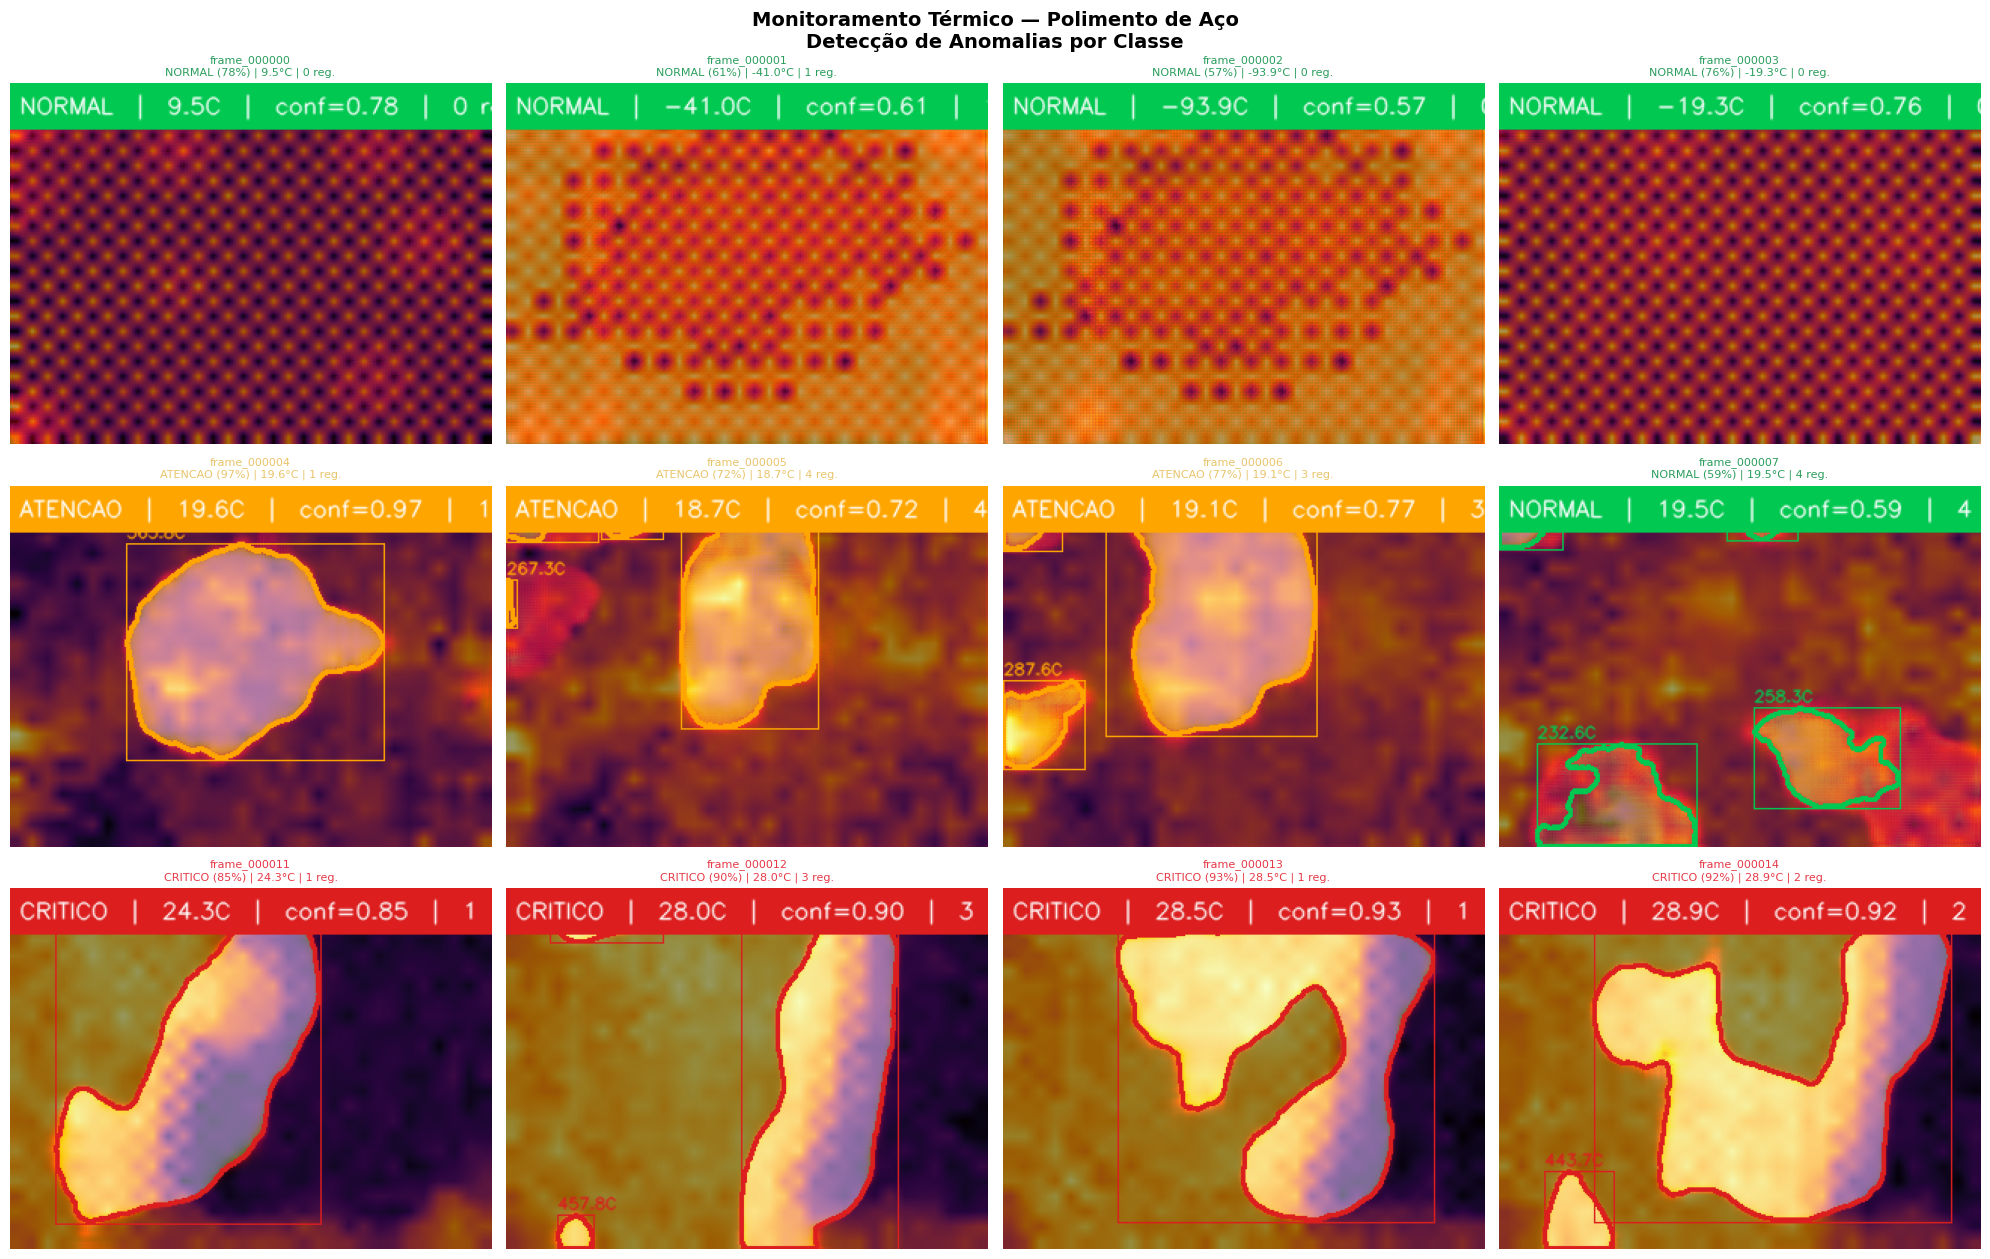

Grade salva em /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/monitoramento-termico/resultados/grade_inferencia.png


In [25]:
# ════════════════════════════════════════════════════════════
#  15. GRADE DE INFERÊNCIA — VISUALIZAÇÃO
# ════════════════════════════════════════════════════════════
print("\nCarregando pipeline para inferência...")
cls_inf, un_inf, cfg_inf = carregar_pipeline(CHECKPOINTS_DIR, device)

frames_gray = sorted(FRAMES_MODELO.glob("*.png"))
# Mostra amostras representativas de cada classe
sample_indices = []
for cls_name in CLASS_NAMES:
    cls_frames = [i for i, fp in enumerate(frames_gray)
                  if FRAME_META.get(fp.stem, {}).get("label") == cls_name]
    if cls_frames:
        sample_indices.extend(cls_frames[:4])  # 4 por classe → 12 total

sample_indices = sample_indices[:12]

fig, axes = plt.subplots(3, 4, figsize=(20, 13))
fig.suptitle("Monitoramento Térmico — Polimento de Aço\nDetecção de Anomalias por Classe",
             fontsize=14, fontweight="bold")

for ax, idx in zip(axes.flat, sample_indices):
    fp       = frames_gray[idx]
    stem     = fp.stem
    mean_abs = FRAME_META.get(stem, {}).get("mean_abs", G_MEAN)
    gray_np  = np.array(Image.open(fp).convert("L"))

    overlay, probs, label, conf, score, temp, regioes = inferir_frame(
        gray_np, mean_abs, cls_inf, un_inf, cfg_inf, device
    )
    cor = {v: k for k, v in CLASS_COLORS.items()}
    ax.imshow(overlay)
    ax.set_title(
        f"{stem}\n{label.upper()} ({conf:.0%}) | {temp:.1f}°C | {len(regioes)} reg.",
        color={
            "normal": "#2a9d5c", "atencao": "#e9c46a", "critico": "#e63946"
        }.get(label, "gray"),
        fontsize=8
    )
    ax.axis("off")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "grade_inferencia.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Grade salva em {RESULTS_DIR / 'grade_inferencia.png'}")

In [26]:
# ════════════════════════════════════════════════════════════
#  16. EXPORTAR TODOS OS FRAMES MARCADOS + RELATÓRIO
# ════════════════════════════════════════════════════════════
print(f"\nExportando frames marcados ({len(frames_gray)} frames)...")
relatorio = []

for fp in tqdm(frames_gray, unit="frame"):
    stem     = fp.stem
    info     = FRAME_META.get(stem, {})
    mean_abs = info.get("mean_abs", G_MEAN)
    gray_np  = np.array(Image.open(fp).convert("L"))

    overlay, probs, label, conf, score, temp, regioes = inferir_frame(
        gray_np, mean_abs, cls_inf, un_inf, cfg_inf, device
    )
    Image.fromarray(overlay).save(FRAMES_MARCADOS / fp.name)

    relatorio.append({
        "frame"       : stem,
        "label_real"  : info.get("label", ""),
        "label_pred"  : label,
        "confianca"   : round(conf, 4),
        "temp_media"  : round(temp, 2),
        "anomalia_pct": round(score, 3),
        "num_regioes" : len(regioes),
        "regioes"     : regioes,
    })

with open(RESULTS_DIR / "relatorio_anomalias.json", "w", encoding="utf-8") as jf:
    json.dump(relatorio, jf, indent=2, ensure_ascii=False)

# Resumo por classe predita
from collections import Counter
pred_dist = Counter(r["label_pred"] for r in relatorio)
real_dist = Counter(r["label_real"] for r in relatorio)

print(f"\n{'='*60}")
print("  RESUMO DO RELATÓRIO")
print(f"{'='*60}")
print(f"  Total de frames : {len(relatorio)}")
print(f"  Labels reais    : {dict(real_dist)}")
print(f"  Predições       : {dict(pred_dist)}")
print(f"  Frames marcados : {FRAMES_MARCADOS}")
print(f"  Relatório JSON  : {RESULTS_DIR / 'relatorio_anomalias.json'}")


Exportando frames marcados (1992 frames)...


100%|██████████| 1992/1992 [02:04<00:00, 16.00frame/s]


  RESUMO DO RELATÓRIO
  Total de frames : 1992
  Labels reais    : {'normal': 1022, 'atencao': 264, 'critico': 706}
  Predições       : {'normal': 971, 'atencao': 324, 'critico': 697}
  Frames marcados : /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/monitoramento-termico/frames_marcados
  Relatório JSON  : /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/monitoramento-termico/resultados/relatorio_anomalias.json


In [27]:
# ════════════════════════════════════════════════════════════
#  17. EXPORTAR PARA DEPLOY (TORCHSCRIPT)
# ════════════════════════════════════════════════════════════
print("\nExportando modelos para TorchScript...")
H, W = cfg_inf["img_size"]

cls_inf.eval()
un_inf.eval()

dummy_2ch = torch.randn(1, 2, H, W).to(device)
dummy_3ch = torch.randn(1, 3, H, W).to(device)

try:
    torch.jit.trace(cls_inf, dummy_2ch).save(str(CHECKPOINTS_DIR / "classifier_scripted.pt"))
    torch.jit.trace(un_inf,  dummy_3ch).save(str(CHECKPOINTS_DIR / "unet_scripted.pt"))
    print("TorchScript salvo ✓")
except Exception as e:
    print(f"⚠️  TorchScript falhou (Grad-CAM usa python puro): {e}")
    print("   Use torch.save() para deploy — os .pt já estão salvos.")

print(f"\n✅ Pipeline completo.")
print(f"   Checkpoints : {CHECKPOINTS_DIR}")
print(f"   Resultados  : {RESULTS_DIR}")
print(f"   Frames      : {FRAMES_MARCADOS}")
print()
print("=" * 60)
print("  USO EM TEMPO REAL (integração com câmera/stream):")
print("  ─────────────────────────────────────────────────")
print("  from 02_treinamento_modelo import carregar_pipeline, inferir_frame")
print("  cls, unet, cfg = carregar_pipeline(CHECKPOINTS_DIR, device)")
print("  while True:")
print("      frame = captura_frame_termico()  # seu código de captura")
print("      overlay, probs, label, conf, score, temp, regioes = \\")
print("          inferir_frame(frame, mean_abs_real, cls, unet, cfg, device)")
print("      cv2.imshow('ThermalWatch', overlay)")
print("=" * 60)


Exportando modelos para TorchScript...
TorchScript salvo ✓

✅ Pipeline completo.
   Checkpoints : /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/monitoramento-termico/checkpoints
   Resultados  : /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/monitoramento-termico/resultados
   Frames      : /mnt/c/Users/cesar.macieira/Desktop/Trabalho/Python_312/monitoramento-termico/frames_marcados

  USO EM TEMPO REAL (integração com câmera/stream):
  ─────────────────────────────────────────────────
  from 02_treinamento_modelo import carregar_pipeline, inferir_frame
  cls, unet, cfg = carregar_pipeline(CHECKPOINTS_DIR, device)
  while True:
      frame = captura_frame_termico()  # seu código de captura
      overlay, probs, label, conf, score, temp, regioes = \
          inferir_frame(frame, mean_abs_real, cls, unet, cfg, device)
      cv2.imshow('ThermalWatch', overlay)
